In [12]:
import json, glob, ast, pickle
import numpy as np
import statistics
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

In [2]:
path_string_to_tuple = lambda x : tuple(int(n) for n in x.split('.'))

from src.network_utils import create_network

# Analysis of simulated walk statistics

In [3]:
paths_filename_biased = 'out/sim_output_source_diffusion_combined.json'
paths_filename_uniform = 'out/sim_output_source_diffusion_uniform_combined.json'

In [17]:
# Calculate length of paths

path_lengths_biased = {}
with open(paths_filename_biased, 'r') as f:
    try :
        path_counts_biased = json.load(f)
        path_counts_biased = {int(source) : path_counts for source, path_counts in path_counts_biased.items()}
    except json.JSONDecodeError:
        print(f"Error decoding JSON from file: {paths_filename_biased}")
    
    for source, paths in path_counts_biased.items():
        for path, c in paths.items():
            path_lengths_biased[path] = len(path_string_to_tuple(path))

path_lengths_uniform = {}
with open(paths_filename_uniform, 'r') as f:
    try :
        path_counts_uniform = json.load(f)
        path_counts_uniform = {int(source) : path_counts for source, path_counts in path_counts_uniform.items()}
    except json.JSONDecodeError:
        print(f"Error decoding JSON from file: {paths_filename_uniform}")
    
    for target, paths in path_counts_uniform.items():
        for path, c in paths.items():
            path_lengths_uniform[path] = len(path_string_to_tuple(path))

In [18]:
n_paths_per_source = sum(list(path_counts_biased.values())[0].values())

average_path_lengths = {}
for source, paths in path_counts_biased.items() :
    average_path_lengths[source] = sum(
        path_lengths_biased[path] * c for path, c in paths.items()
    ) / n_paths_per_source

Text(0, 0.5, 'Number of sources')

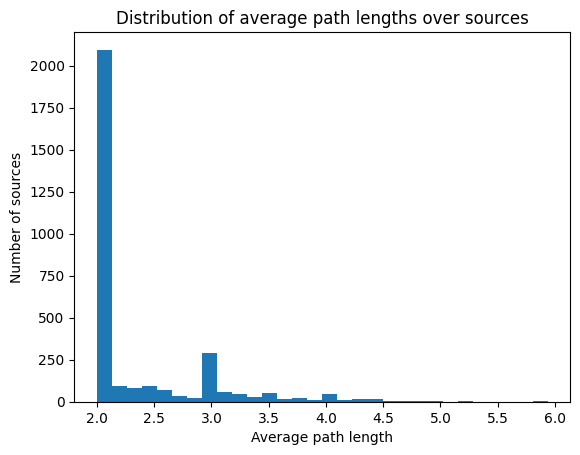

In [19]:
plt.hist(list(average_path_lengths.values()), bins=30);
plt.title('Distribution of average path lengths over sources')
plt.xlabel('Average path length')
plt.ylabel('Number of sources')

Peaks at 2, 3, 4... represent closed circuits?

In [21]:
# Summary statistics
print("Biased paths")
print(f"Mean path length: {statistics.mean(path_lengths_biased.values())}")
print(f"Min and max path lengths: ({min(path_lengths_biased.values())}, {max(path_lengths_biased.values())})")

print("\nUniform paths")
print(f"Mean path length: {statistics.mean(path_lengths_uniform.values())}")
print(f"Min and max path lengths: ({min(path_lengths_uniform.values())}, {max(path_lengths_uniform.values())})")

Biased paths
Mean path length: 4.154956043218576
Min and max path lengths: (2, 17)

Uniform paths
Mean path length: 4.132841328413284
Min and max path lengths: (2, 16)


In [27]:
ls_biased = np.array(list(path_lengths_biased.values()))
vals, bins = np.histogram(ls_biased, bins=range(1, max(ls_biased) + 1))
with open('path_lengths_hist_biased.pkl', 'wb') as f: pickle.dump((vals, bins), f)
vals, bins

(array([   0, 6785, 6529, 5163, 4677, 3019, 1871,  976,  446,  198,   83,
          25,   21,    5,    2,    2]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]))

In [28]:
ls_uniform = np.array(list(path_lengths_uniform.values()))
vals, bins = np.histogram(ls_uniform, bins=range(1, max(ls_uniform) + 1))
with open('path_lengths_hist_uniform.pkl', 'wb') as f: pickle.dump((vals, bins), f)
vals, bins

(array([   0, 6804, 6792, 5701, 5207, 3266, 1854,  888,  393,  165,   52,
          31,    5,    4,    3]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]))

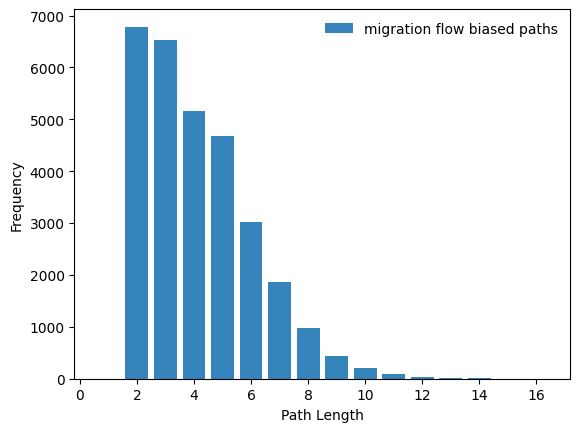

In [30]:
with open('path_lengths_hist_biased.pkl', 'rb') as f : vals, bins = pickle.load(f)
plt.bar(bins[:-1], vals, label='migration flow biased paths', alpha=0.9)
# with open('path_lengths_hist_uniform.pkl', 'rb') as f : vals, bins = pickle.load(f)
# plt.bar(bins[:-1], vals, label='uniform paths', alpha=0.5)

plt.xlabel('Path Length')
plt.ylabel('Frequency')
plt.legend(frameon=False)

plt.savefig('figs/path_lengths_hist_biased.png', dpi=300, bbox_inches='tight')

In [45]:
ds_basename = 'Weighted_network_data_3'
df = pd.read_csv(f'data/{ds_basename}.csv')
G = create_network(df)
name_to_idx = json.load(open(f'data/{ds_basename}_name_to_id.json', 'r'))
G = nx.relabel_nodes(G, name_to_idx)

##### Commenting out the below — not sure what we were doing and whether we need it

# for fname in data_files_biased :
#     with open(fname, 'r') as f :
#         try :
#             path_counts = json.load(f)
#         except json.JSONDecodeError:
#             print(f"Error decoding JSON from file: {fname}")
#             continue
        
#         # Count number of paths that reach target
#         source_to_target_prob = {}
#         for target, paths in path_counts.items() :  # Target dependence doesn't really matter here
#             source_to_target_prob[target] = [0,0,0]   # (reach, reach sink, don't reach)
#             for path, c in paths.items() :
#                 path = path_string_to_tuple(path)
#                 if path[-1] == target :
#                     source_to_target_prob[target][0] += c  # Record number of paths that reach target
#                 elif G.out_degree(path[-1]) == 0 : # If last node is a sink
#                     source_to_target_prob[target][1] += c
#                 else :
#                     print(path)

#         # Take hazard mode for each step for this node
#         # for i in range(max_step) :
#         #     time_agg_hazards[i,np.argmax(hazards_by_step[i])] += 1

In [37]:
#network analysis
disconnected_edges = []
for component in nx.weakly_connected_components(G):  # for directed graph G
    subgraph = G.subgraph(component)
    if subgraph.number_of_nodes() == 2 and subgraph.number_of_edges() == 1:
        disconnected_edges.extend(subgraph.edges())

print(f"Number of disconnected edges (2-node components): {len(disconnected_edges)}")

largest_cc_nodes = max(nx.weakly_connected_components(G),key=len) #4765 nodes
largest_cc_subgraph = G.subgraph(largest_cc_nodes).copy()

zero_out_degree_nodes = [node for node in largest_cc_subgraph.nodes if largest_cc_subgraph.out_degree(node) == 0]
#1584

nonzero_out_degree_nodes = [node for node in largest_cc_subgraph.nodes if largest_cc_subgraph.out_degree(node) > 0]


# Remove self-loops from the largest connected component subgraph
largest_cc_subgraph.remove_edges_from(nx.selfloop_edges(largest_cc_subgraph))


Number of disconnected edges (2-node components): 246


Text(0, 0.5, 'Frequency')

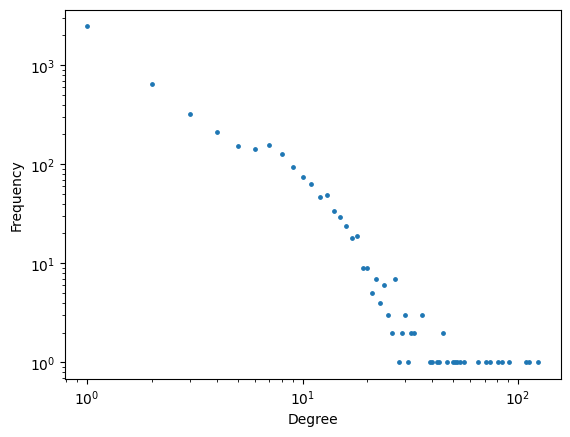

In [47]:
# TODO: log-binning

degree_hist = nx.degree_histogram(largest_cc_subgraph)
# plt.bar(range(0, len(degree_hist)), degree_hist)
plt.scatter(range(0, len(degree_hist)), degree_hist, s=6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree')
plt.ylabel('Frequency')

# Distribution of hazards as a funciton of path length / time

In [ ]:
settlement_IDPs = np.loadtxt('data/settlement_IDPs.txt', dtype=int)
hazard_list = ast.literal_eval(open('data/hazards_set.txt').read())

max_step = 5
time_agg_hazards = np.zeros((max_step, len(hazard_list)))

with open(paths_filename_biased, 'r') as f :
    try :
        path_counts = json.load(f)
    except json.JSONDecodeError:
        print(f"Error decoding JSON from file: {paths_filename_biased}")
        exit()
    
    # Calulate most likely hazard by step
    # hazards_by_step = {n : [0]*len(hazard_list) for n in range(max_step)}
    hazards_by_step = {n : np.zeros(len(hazard_list)) for n in range(max_step)}
    for source, paths in path_counts.items() :
        for path, c in paths.items() :
            path = path_string_to_tuple(path)
            for i, node in enumerate(path[:max_step]) :
                # Add number of IDPs to most likely settlement hazard for this node
                
                # hazard_mode_idx = np.argmax(settlement_IDPs[node])
                # hazards_by_step[i][hazard_mode_idx] += c

                hazards_by_step[i] += settlement_IDPs[node]

        # Take hazard mode for each step for this node
        for i in range(max_step) :
            time_agg_hazards[i,np.argmax(hazards_by_step[i])] += 1

In [60]:
hazards_by_step

{0: array([339032.,  16165., 309386.,  46854.,   1795.]),
 1: array([402529.,  47582., 448148., 149906.,   1053.]),
 2: array([300738.,  22194., 342296., 111314.,    959.]),
 3: array([193454.,  20603., 210007., 171233.,   2372.]),
 4: array([160927.,   9421., 143317.,  76773.,    595.])}

In [63]:
time_agg_hazards = np.array(list(hazards_by_step.values()))

In [64]:
time_agg_hazards

array([[339032.,  16165., 309386.,  46854.,   1795.],
       [402529.,  47582., 448148., 149906.,   1053.],
       [300738.,  22194., 342296., 111314.,    959.],
       [193454.,  20603., 210007., 171233.,   2372.],
       [160927.,   9421., 143317.,  76773.,    595.]])

In [65]:
time_agg_hazards.sum(axis=1, keepdims=True)

array([[ 713232.],
       [1049218.],
       [ 777501.],
       [ 597669.],
       [ 391033.]])

In [66]:
time_agg_hazards_norm = time_agg_hazards / time_agg_hazards.sum(axis=1, keepdims=True)  # Not dividing by num files because some files are empty

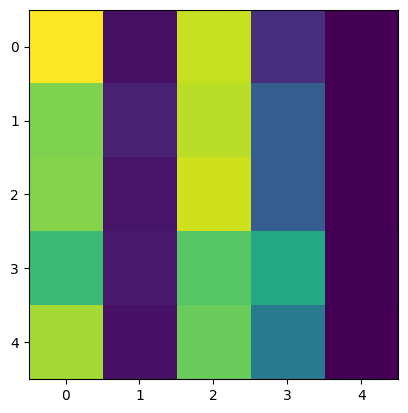

In [67]:
plt.imshow(time_agg_hazards_norm)

In [68]:
time_agg_hazards_norm

array([[0.47534603, 0.02266443, 0.43378031, 0.06569251, 0.00251671],
       [0.38364668, 0.04534997, 0.42712573, 0.14287403, 0.0010036 ],
       [0.38680079, 0.0285453 , 0.44025152, 0.14316895, 0.00123344],
       [0.32368083, 0.03447226, 0.35137677, 0.28650139, 0.00396875],
       [0.41154327, 0.0240926 , 0.36650871, 0.19633381, 0.00152161]])

In [69]:
# pd.DataFrame(time_agg_hazards_norm, index=range(max_step), columns=hazard_list).to_csv('time_agg_hazards.csv')
hazards_dist = pd.DataFrame(time_agg_hazards_norm, index=range(max_step), columns=hazard_list)
hazards_dist

,Drought,Eviction,Conflict,Flood,Other
0,0.475346,0.022664,0.433780,0.065693,0.002517
1,0.383647,0.045350,0.427126,0.142874,0.001004
2,0.386801,0.028545,0.440252,0.143169,0.001233
3,0.323681,0.034472,0.351377,0.286501,0.003969
4,0.411543,0.024093,0.366509,0.196334,0.001522


In [70]:
hazards_dist.to_csv('out/hazards_dist_time.csv')

In [ ]:
settlement_IDPs = np.loadtxt('settlement_IDPs.txt', dtype=int)
hazard_list = ast.literal_eval(open('hazards_set.txt').read())

max_step = 5
time_agg_hazards = np.zeros((max_step, len(hazard_list)))
for fname in data_files_uniform :
    with open(fname, 'r') as f :
        try :
            path_counts = json.load(f)
        except json.JSONDecodeError:
            print(f"Error decoding JSON from file: {fname}")
            continue
        
        # Calulate most likely hazard by step
        # hazards_by_step = {n : [0]*len(hazard_list) for n in range(max_step)}
        hazards_by_step = {n : np.zeros(len(hazard_list)) for n in range(max_step)}
        for target, paths in path_counts.items() :  # Target dependence doesn't really matter here
            for path, c in paths.items() :
                path = path_string_to_tuple(path)
                for i, node in enumerate(path[:max_step]) :
                    # Add number of IDPs to most likely settlement hazard for this node
                    
                    # hazard_mode_idx = np.argmax(settlement_IDPs[node])
                    # hazards_by_step[i][hazard_mode_idx] += c

                    hazards_by_step[i] += settlement_IDPs[node]

        # Take hazard mode for each step for this node
        for i in range(max_step) :
            time_agg_hazards[i,np.argmax(hazards_by_step[i])] += 1

# Runs in around 6m

In [ ]:
# Not dividing by num files because some files are empty
time_agg_hazards_norm = time_agg_hazards / time_agg_hazards.sum(axis=1, keepdims=True)
hazards_dist = pd.DataFrame(time_agg_hazards_norm, index=range(max_step), columns=hazard_list)
hazards_dist.to_csv('hazards_dist_time_uniform.csv')